In [1]:
import pandas as pd

df = pd.read_csv('/job_postings_clean.csv')

print(df.head())

       job_id              company_name  \
0  3901353701               HHS Careers   
1  3901466208        Health New England   
2  3902944016  Alzheimer's Association®   
3  3903825824             Carbon Health   
4  3891289542           The Job Network   

                                       title role_category  \
0  Supervisory Physician (Clinical Director)         Other   
1                           Legal Specialist         Other   
2                  Director of Public Policy         Other   
3                    Clinic Medical Director         Other   
4           Case Manager RN - PAMC Case Mgmt       Manager   

                                         description  salary_available  \
0  Summary\n\nThis position serves as the Clinica...             False   
1  SUMMARY:  The Legal Specialist performs a comb...             False   
2  Position Summary\n\nThe Director of Mississipp...             False   
3  As a physician-founded and led organization, e...             False  

In [2]:
print(df.shape)

(2854, 12)


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_id             2854 non-null   int64  
 1   company_name       2854 non-null   object 
 2   title              2854 non-null   object 
 3   role_category      2854 non-null   object 
 4   description        2854 non-null   object 
 5   salary_available   2854 non-null   bool   
 6   max_annual_salary  781 non-null    float64
 7   min_annual_salary  781 non-null    float64
 8   pay_period         867 non-null    object 
 9   clean_location     2854 non-null   object 
 10  city               2535 non-null   object 
 11  state              2291 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 248.2+ KB
None


In [4]:
skills = {
    'Technical Tools': [
        'sql', 'excel', 'python', 'r', 'tableau', 'power bi',
        'bigquery', 'sas', 'epic', 'cerner', 'azure', 'aws'],
    'Healthcare Domain': [
        'cms', 'medicaid', 'medicare', 'hipaa', 'revenue cycle',
        'risk adjustment', 'value-based care', 'population health',
        'prior authorization', 'claims', 'icd', 'cpt', 'hcc', 'hedis' ],
    'Operational Skills': [
        'project management', 'stakeholder management',
        'process improvement', 'lean', 'six sigma', 'agile',
        'pmp', 'capm' ]
}

# Prints the number of keywords in each category
for category, keyword_list in skills.items():
    print(f"{category}: {len(keyword_list)} keywords")

Technical Tools: 12 keywords
Healthcare Domain: 14 keywords
Operational Skills: 8 keywords


In [5]:
# re module imported to use /b
import re

# Defines a function that checks if a keyword appears in a description
def check_keyword(description, keyword):
    if not isinstance(description, str):
        return 0

    keyword_clean = keyword.strip()

    # \b matches at word boundaries so 'r' only matches the standalone letter
    pattern = r'\b' + re.escape(keyword_clean) + r'\b'

    if re.search(pattern, description, re.IGNORECASE):
        return 1
    else:
        return 0

In [6]:
# Pull three sample descriptions from DataFrame

sample_1 = df['description'].iloc[0]
sample_2 = df['description'].iloc[1]
sample_3 = df['description'].iloc[2]

# Print the first 200 characters of each so you can read them
print("Sample 1 preview:")
print(sample_1[:400])
print()

print("Sample 2 preview:")
print(sample_2[:400])
print()

print("Sample 3 preview:")
print(sample_3[:400])

Sample 1 preview:
Summary

This position serves as the Clinical Director for the Pine Ridge Service Unit located in Pine Ridge, SD. The incumbent provides clinical medical services to eligible patients and supervises clinical staff. The incumbent works on a regularly assigned rotation or call-back basis to provide continuity of medical services during evenings, nights, holidays, and weekends. This position reports 

Sample 2 preview:
SUMMARY:  The Legal Specialist performs a combination of functions shown below based on the needs of the Legal department and the company, and will assist the Staff Attorney, the Assistant General Counsel, the VP/General Counsel, and other key stakeholders. 
ESSENTIAL FUNCTIONS:Contract /Document Creation, Preparation and Management – 30% Prepares, manages and tracks contracts, amendments and cont

Sample 3 preview:
Position Summary

The Director of Mississippi Public Policy (1) serves as the principal staff for state government affairs and chief lobbyist 

In [7]:
# Test check_keyword on sample descriptions

print("Testing Sample 1:")
print(f"  'excel' found: {check_keyword(sample_1, 'excel')}")
print(f"  'sql' found: {check_keyword(sample_1, 'sql')}")
print(f"  'medicare' found: {check_keyword(sample_1, 'medicare')}")
print()

print("Testing Sample 2:")
print(f"  'hipaa' found: {check_keyword(sample_2, 'hipaa')}")
print(f"  'project management' found: {check_keyword(sample_2, 'project management')}")
print(f"  'python' found: {check_keyword(sample_2, 'python')}")
print()

print("Testing Sample 3:")
print(f"  'tableau' found: {check_keyword(sample_3, 'tableau')}")
print(f"  'revenue cycle' found: {check_keyword(sample_3, 'revenue cycle')}")
print(f"  'capm' found: {check_keyword(sample_3, 'capm')}")

Testing Sample 1:
  'excel' found: 0
  'sql' found: 0
  'medicare' found: 0

Testing Sample 2:
  'hipaa' found: 1
  'project management' found: 0
  'python' found: 0

Testing Sample 3:
  'tableau' found: 0
  'revenue cycle' found: 0
  'capm' found: 0


In [8]:
# Creates a flat list of all keywords from all categories

all_keywords = []

for category, keyword_list in skills.items():
    for keyword in keyword_list:
        all_keywords.append(keyword)

# Confirms the total count
print(f"Total keywords to scan: {len(all_keywords)}")
print(all_keywords)

Total keywords to scan: 34
['sql', 'excel', 'python', 'r', 'tableau', 'power bi', 'bigquery', 'sas', 'epic', 'cerner', 'azure', 'aws', 'cms', 'medicaid', 'medicare', 'hipaa', 'revenue cycle', 'risk adjustment', 'value-based care', 'population health', 'prior authorization', 'claims', 'icd', 'cpt', 'hcc', 'hedis', 'project management', 'stakeholder management', 'process improvement', 'lean', 'six sigma', 'agile', 'pmp', 'capm']


In [9]:
# Applies check_keyword across every row for every keyword

description_column = 'description'

for keyword in all_keywords:

    column_name = keyword.replace(' ', '_')


    df[column_name] = df[description_column].apply(
        lambda desc: check_keyword(desc, keyword)
    )

print("Keyword extraction complete")
print(f"DataFrame now has {len(df.columns)} columns")

Keyword extraction complete
DataFrame now has 46 columns


In [10]:
# Checks the first 5 rows

check_columns = ['sql', 'excel', 'medicare', 'revenue_cycle', 'project_management']

print("Sample verification — first 5 rows:")
print(df[['description'] + check_columns].head())

Sample verification — first 5 rows:
                                         description  sql  excel  medicare  \
0  Summary\n\nThis position serves as the Clinica...    0      0         0   
1  SUMMARY:  The Legal Specialist performs a comb...    0      0         0   
2  Position Summary\n\nThe Director of Mississipp...    0      0         0   
3  As a physician-founded and led organization, e...    0      0         0   
4  Description\n\nUnder general supervision this ...    0      0         0   

   revenue_cycle  project_management  
0              0                   0  
1              0                   0  
2              0                   0  
3              0                   0  
4              0                   0  


In [11]:
# Sums each keyword column to get frequency counts

keyword_columns = [kw.replace(' ', '_') for kw in all_keywords]

# Creates a Series with keyword names and their counts
frequency_counts = df[keyword_columns].sum()

# Converts to a DataFrame for easier analysis
skill_frequency = frequency_counts.reset_index()
skill_frequency.columns = ['skill', 'mention_count']

# Adds a percentage column
skill_frequency['percent_of_postings'] = (
    skill_frequency['mention_count'] / len(df) * 100
).round(1)

# Sort by mention count descending so highest appears first
skill_frequency = skill_frequency.sort_values(
    'mention_count', ascending=False
).reset_index(drop=True)

# Add a rank column
skill_frequency['rank'] = skill_frequency.index + 1

print("Skill frequency table built successfully")
print(f"Total skills ranked: {len(skill_frequency)}")
print()
print(skill_frequency.head(10))

Skill frequency table built successfully
Total skills ranked: 34

                 skill  mention_count  percent_of_postings  rank
0                excel            594                 20.8     1
1             medicare            532                 18.6     2
2             medicaid            436                 15.3     3
3               claims            338                 11.8     4
4   project_management            310                 10.9     5
5                hipaa            284                 10.0     6
6        revenue_cycle            270                  9.5     7
7  process_improvement            197                  6.9     8
8                  cms            149                  5.2     9
9                 epic            149                  5.2    10


In [12]:
# Builds a lookup dictionary mapping each keyword to its category

keyword_to_category = {}

for category, keyword_list in skills.items():
    for keyword in keyword_list:
        keyword_to_category[keyword] = category


skill_frequency['category'] = skill_frequency['skill'].apply(
    lambda skill_name: keyword_to_category.get(
        skill_name.replace('_', ' '), 'Unknown'
    )
)

print("Categories added")
print(skill_frequency[['rank', 'skill', 'category',
                         'mention_count', 'percent_of_postings']].head(15))

Categories added
    rank                skill            category  mention_count  \
0      1                excel     Technical Tools            594   
1      2             medicare   Healthcare Domain            532   
2      3             medicaid   Healthcare Domain            436   
3      4               claims   Healthcare Domain            338   
4      5   project_management  Operational Skills            310   
5      6                hipaa   Healthcare Domain            284   
6      7        revenue_cycle   Healthcare Domain            270   
7      8  process_improvement  Operational Skills            197   
8      9                  cms   Healthcare Domain            149   
9     10                 epic     Technical Tools            149   
10    11                  cpt   Healthcare Domain            134   
11    12                  icd   Healthcare Domain            130   
12    13                  sql     Technical Tools            115   
13    14    population_health  

Chart saved as top_20_healthcare_skills.png


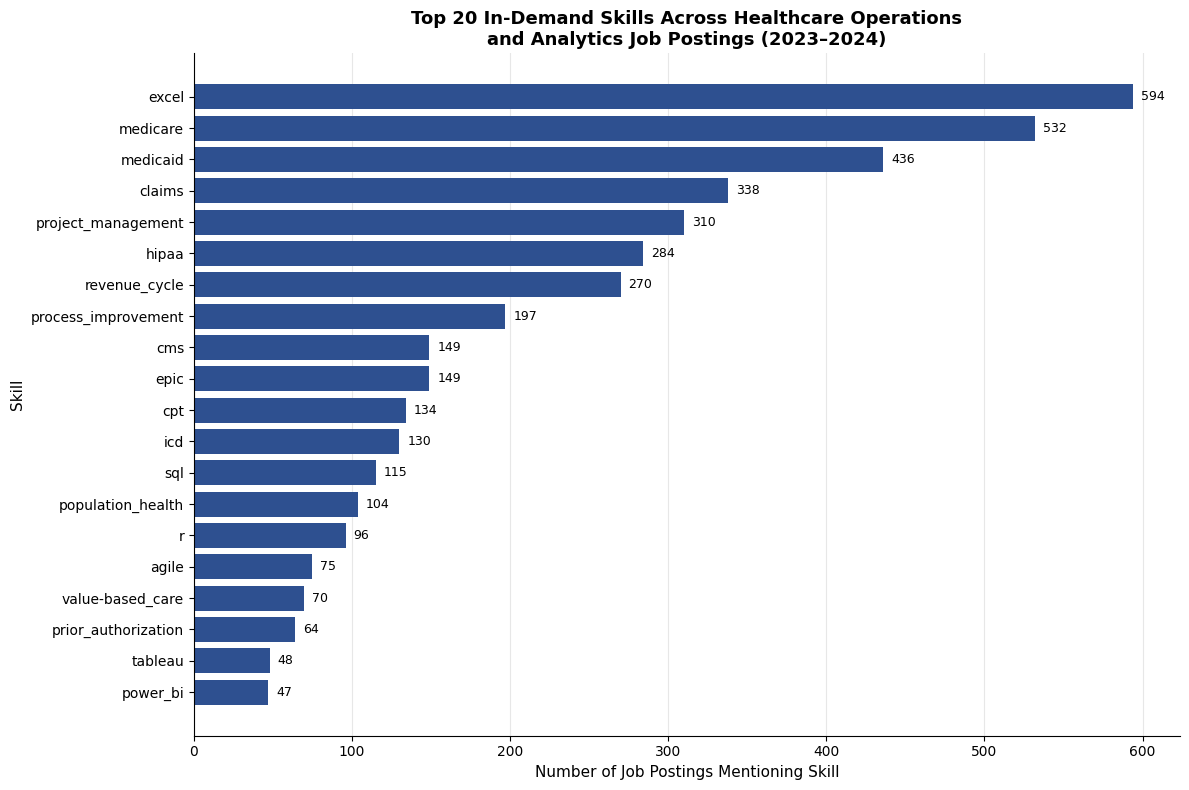

In [13]:
import matplotlib.pyplot as plt

# Top 20 skills
top_20 = skill_frequency.head(20)

# Set up the figure size
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bars
bars = ax.barh(
    top_20['skill'],
    top_20['mention_count'],
    color='#2E5090'
)

# Add data labels at the end of each bar showing the count
for bar, count in zip(bars, top_20['mention_count']):
    ax.text(
        bar.get_width() + 5,  # position slightly past the end of the bar
        bar.get_y() + bar.get_height() / 2,  # centered vertically on the bar
        str(count),  # the label text
        va='center',
        fontsize=9
    )

# Labels and title
ax.set_xlabel('Number of Job Postings Mentioning Skill', fontsize=11)
ax.set_ylabel('Skill', fontsize=11)
ax.set_title(
    'Top 20 In-Demand Skills Across Healthcare Operations\nand Analytics Job Postings (2023–2024)',
    fontsize=13,
    fontweight='bold'
)

# Invert y axis so the highest ranked skill appears at the top
ax.invert_yaxis()

# Remove the top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add light horizontal gridlines for readability
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

# Saves the chart as a PNG file
plt.savefig('top_20_healthcare_skills.png', dpi=150, bbox_inches='tight')
print("Chart saved as top_20_healthcare_skills.png")

plt.show()